In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , roc_auc_score
from sklearn.preprocessing import LabelEncoder , StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense , Dropout , BatchNormalization , Flatten , Input
from scikeras.wrappers import KerasRegressor
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import BaggingRegressor

In [7]:
df = pd.read_csv("/content/train.csv")
df.drop(columns=["id"] , inplace = True)
df.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [8]:
df = df[~df["loan_paid_back"].isna()]

In [9]:
df.describe()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,22549.000000,22549.000000,22549.000000,22549.000000,22549.000000,22549.000000
mean,48131.374049,0.120566,680.389374,14986.150383,12.366716,0.795911
std,26928.591541,0.068623,55.344709,6856.478667,2.009199,0.403043
min,6100.320000,0.011000,437.000000,514.320000,4.010000,0.000000
25%,27676.730000,0.072000,646.000000,10279.620000,10.990000,1.000000
50%,46426.380000,0.096000,682.000000,14956.060000,12.370000,1.000000
75%,61114.540000,0.156000,719.000000,18700.320000,13.690000,1.000000
max,293811.690000,0.566000,848.000000,48959.950000,20.480000,1.000000


In [10]:
gender_encoder = LabelEncoder()
marital_encoder = LabelEncoder()
education_encoder = LabelEncoder()
employment_encoder = LabelEncoder()
loan_purpose_encoder = LabelEncoder()
grade_subgrade_encode = LabelEncoder()

df["gender"] = gender_encoder.fit_transform(df["gender"])
df["marital_status"] = marital_encoder.fit_transform(df["marital_status"])
df["education_level"] = education_encoder.fit_transform(df["education_level"])
df["employment_status"] = employment_encoder.fit_transform(df["employment_status"])
df["loan_purpose"] = loan_purpose_encoder.fit_transform(df["loan_purpose"])
df["grade_subgrade"] = grade_subgrade_encode.fit_transform(df["grade_subgrade"])

<Axes: >

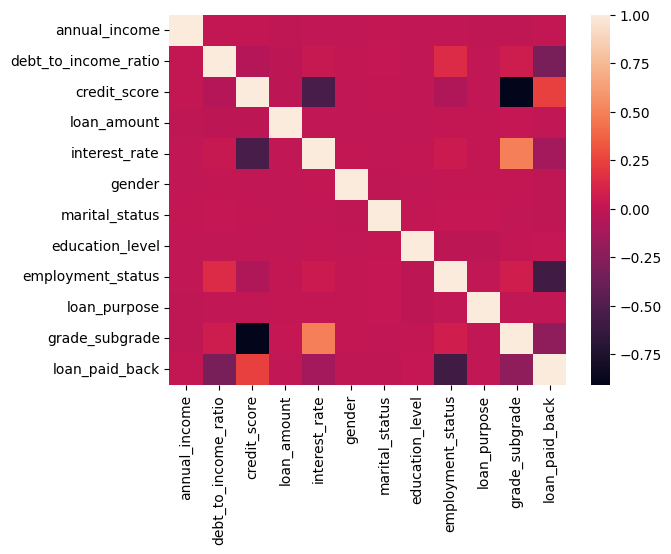

In [11]:
sns.heatmap(df.corr())

In [12]:
x = df.iloc[: , :-1]
y = df.iloc[: , -1]

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=1)

In [13]:
scaler = StandardScaler()

x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()

x_train_scaled[['annual_income' ,'debt_to_income_ratio' ,'credit_score' ,'loan_amount' , 'interest_rate' ]] = scaler.fit_transform(x_train_scaled[['annual_income' ,'debt_to_income_ratio' ,'credit_score' ,'loan_amount' , 'interest_rate' ]])
x_test_scaled[['annual_income' ,'debt_to_income_ratio' ,'credit_score' ,'loan_amount' , 'interest_rate' ]] = scaler.transform(x_test_scaled[['annual_income' ,'debt_to_income_ratio' ,'credit_score' ,'loan_amount' , 'interest_rate' ]])

In [14]:
x_train_scaled.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
20105,-0.912404,0.301208,0.838677,-0.704750,-0.698394,0,2,1,0,3,14
3259,0.419138,-0.401135,0.026463,-1.040115,-0.648567,0,2,1,0,4,13
9533,-0.409375,-0.883996,-0.948194,0.607511,0.547278,1,1,2,0,3,16
16257,0.759100,-1.015685,1.235759,-0.634499,-1.729811,1,2,0,2,2,8
6383,0.113289,-1.220535,0.531841,-0.261039,-0.434312,0,2,0,0,2,11


In [ ]:
model = Sequential()

model.add(Input(shape = (x_train_scaled.shape[1] , )))

model.add(Dense(128 , activation = 'relu' , kernel_regularizer=tf.keras.regularizers.L2(0.0005)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(128 , activation = 'relu' , kernel_regularizer=tf.keras.regularizers.L2(0.0005)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(64 , activation = 'relu' , kernel_regularizer=tf.keras.regularizers.L2(0.0005)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(64 , activation = 'relu' , kernel_regularizer=tf.keras.regularizers.L2(0.0005)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(1 , activation = 'sigmoid'))

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,065 (125.25 KB)

 Trainable params: 31,297 (122.25 KB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
model.compile(loss='binary_crossentropy' , optimizer=tf.keras.optimizers.Adam(learning_rate = 0.0001) , metrics=['accuracy'])

In [ ]:
history = model.fit(x_train_scaled , y_train , epochs=50 , validation_split=0.2 , verbose=1 , batch_size=32)

Epoch 1/50
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.6818 - loss: 0.7885 - val_accuracy: 0.8903 - val_loss: 0.4620
Epoch 2/50
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8611 - loss: 0.5242 - val_accuracy: 0.8989 - val_loss: 0.4199
Epoch 3/50
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8749 - loss: 0.4783 - val_accuracy: 0.9003 - val_loss: 0.4045
Epoch 4/50
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8844 - loss: 0.4555 - val_accuracy: 0.9019 - val_loss: 0.3964
Epoch 5/50
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8857 - loss: 0.4411 - val_accuracy: 0.9008 - val_loss: 0.3887
Epoch 6/50
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8804 - loss: 0.4384 - val_accuracy: 0.9005 - val_loss: 0.3835
Epoch 7/50
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8853 - loss: 0.4310 - val_accuracy: 0.9020 - val_loss: 0.3779
Epoch 8/50
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8828 - loss: 0.4237 -

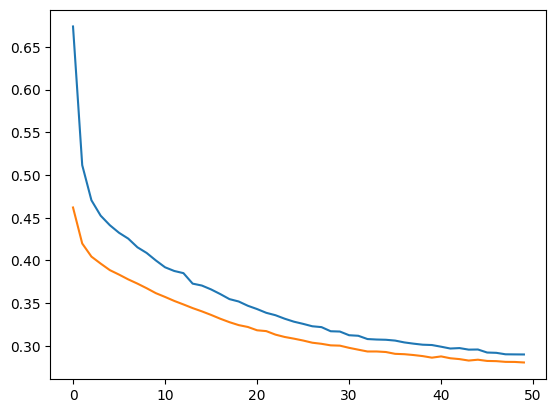

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

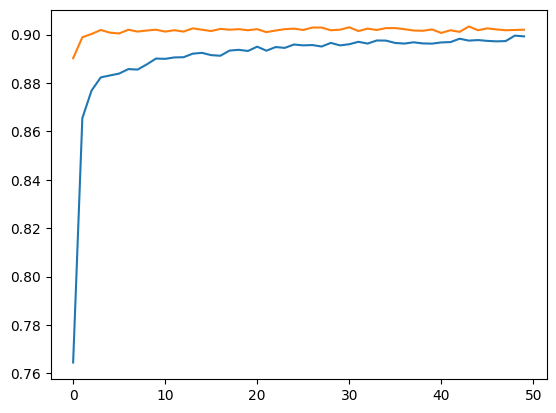

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [ ]:
y_pred_prob = model.predict(x_test_scaled)
roc_auc_score(y_test , y_pred_prob)

352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


np.float64(0.9055903640908027)

**Using bagging of neural network model**

In [ ]:
def build_model():

  model = Sequential()

  model.add(Input(shape = (8 , )))

  model.add(Dense(128 , activation = 'relu' , kernel_regularizer=tf.keras.regularizers.L2(0.0005)))
  model.add(BatchNormalization())
  model.add(Dropout(0.2))

  model.add(Dense(128 , activation = 'relu' , kernel_regularizer=tf.keras.regularizers.L2(0.0005)))
  model.add(BatchNormalization())
  model.add(Dropout(0.2))

  model.add(Dense(64 , activation = 'relu' , kernel_regularizer=tf.keras.regularizers.L2(0.0005)))
  model.add(BatchNormalization())
  model.add(Dropout(0.2))

  model.add(Dense(64 , activation = 'relu' , kernel_regularizer=tf.keras.regularizers.L2(0.0005)))
  model.add(BatchNormalization())
  model.add(Dropout(0.2))

  model.add(Dense(1 , activation = 'sigmoid'))

  model.summary()

  # model.summary()
  model.compile(loss='binary_crossentropy' , optimizer=tf.keras.optimizers.Adam(learning_rate = 0.0001) , metrics=['accuracy'])

  return model

In [ ]:
base_model = KerasRegressor(model=build_model , epochs=10 , batch_size=32 , verbose=1)

In [ ]:
bg = BaggingRegressor(
    estimator=base_model,
    n_estimators=5 ,
    max_samples = 0.8,
    max_features = 0.8,
    bootstrap_features = True ,
    n_jobs = -1,
    verbose = 1
)

In [ ]:
bg.fit(x_train_scaled , y_train)

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:  2.2min finished


BaggingRegressor(bootstrap_features=True,
                 estimator=KerasRegressor(batch_size=32, epochs=10, model=<function build_model at 0x7b9214ae2de0>),
                 max_features=0.8, max_samples=0.8, n_estimators=5, n_jobs=-1,
                 verbose=1)

In [ ]:
y_pred_prob = model.predict(x_test_scaled)
roc_auc_score(y_test , y_pred_prob)


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


np.float64(0.9055903640908027)

In [36]:
test_df = pd.read_csv("/content/test.csv")
test_df.drop(columns=["id"] , inplace = True)
test_df.shape


(254569, 11)

In [37]:

test_df["gender"] = gender_encoder.fit_transform(test_df["gender"])
test_df["marital_status"] = marital_encoder.fit_transform(test_df["marital_status"])
test_df["education_level"] = education_encoder.fit_transform(test_df["education_level"])
test_df["employment_status"] = employment_encoder.fit_transform(test_df["employment_status"])
test_df["loan_purpose"] = loan_purpose_encoder.fit_transform(test_df["loan_purpose"])
test_df["grade_subgrade"] = grade_subgrade_encode.fit_transform(test_df["grade_subgrade"])

In [38]:
test_df_scaled = test_df.copy()
test_df_scaled[['annual_income' ,'debt_to_income_ratio' ,'credit_score' ,'loan_amount' , 'interest_rate' ]] = scaler.transform(test_df_scaled[['annual_income' ,'debt_to_income_ratio' ,'credit_score' ,'loan_amount' , 'interest_rate' ]])


In [40]:
test_df.shape

(254569, 11)

In [34]:
593994 - 848563

-254569

In [ ]:
y_pred_prob = model.predict(test_df_scaled)

7956/7956 ━━━━━━━━━━━━━━━━━━━━ 7s 919us/step


In [ ]:
y_pred_prob

array([[0.9182089 ],
       [0.9905872 ],
       [0.44913486],
       ...,
       [0.9784872 ],
       [0.98952913],
       [0.86182535]], dtype=float32)

In [ ]:
submission = pd.DataFrame({
    'id' : np.arange(593994 , 848563),
    'loan_paid_back' : y_pred_prob.flatten()
})
submission.to_csv('submission.csv' , index = False)

**Using XGBoost**

In [43]:
model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=10,
    use_label_encoder=False,
    objective='binary:logistic',
        eval_metric='auc',
)

In [44]:
grid_search_cv = GridSearchCV(
    estimator = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        use_label_encoder=False
    ),
    param_grid = {
        'n_estimators':[50,100,150,200],
        'learning_rate':[0.1,0.05,0.01,0.005,0.001],
        'max_depth':[3,5,10,15,20,25,30],
        'reg_lambda' : [0.1,0.01,0.001,0.0001,0.00001],
        'booster': ['gbtree', 'gblinear', 'dart', 'gbtree'],
        'subsample' : [0.6,0.8,0.85,0.9,0.95,0.1]
    },
    n_jobs=-1
)

In [ ]:
grid_search_cv.fit(x_train , y_train)

In [ ]:
grid_search_cv.best_params_


In [ ]:
model = grid_search_cv.best_estimator_

In [28]:
model.fit(x_train , y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [20:24:21] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [29]:
y_pred_prob = model.predict_proba(x_test)[: , 1]
y_pred_prob

array([0.00678097, 0.9877522 , 0.00675391, ..., 0.99342185, 0.9088533 ,
       0.9868421 ], dtype=float32)

In [30]:
roc_auc_score(y_test , y_pred_prob)

np.float64(0.900076955765557)

In [41]:
test_df.shape

(254569, 11)

In [42]:
y_pred_prob = model.predict_proba(test_df)[: , 1]
submission = pd.DataFrame({
    'id' : np.arange(593994 , 848563),
    'loan_paid_back' : y_pred_prob.flatten()
})
submission.to_csv('submission.csv' , index = False)